In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (ModelCheckpoint, TensorBoard, ReduceLROnPlateau,
                                        CSVLogger, EarlyStopping)
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout, BatchNormalization, Activation, Add, Flatten, Dense)
from tensorflow.keras.models import Model
import datetime
import pandas as pd
import pickle
import demo_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
model_name = "demo_model"

I0000 00:00:1777611835.047325   16777 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777611835.096392   16777 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777611837.131062   16777 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# load demo data

In [3]:
demo_agesex_features = pd.read_csv("demo_data/demo_asfeats.csv") # ecgId (used for path) + tabular features 
demo_ecgs = ["ecg_%d"%i for i in range(len(demo_agesex_features))] # paths to ecg files, assuming they're numpy arrays
demo_labels = pd.read_csv("demo_data/demo_labels.csv",index_col=0) 

In [12]:
validation_generator.labels.columns

Index(['Non-ST_elevation_(NSTEMI)_myocardial_infarction',
       'ST_elevation_(STEMI)_myocardial_infarction', 'Heart_failure',
       'Unstable_angina', 'Atrial_fibrillation', 'Syncope',
       'Ventricular_tachycardia', 'Cardiac_arrest',
       'Supraventricular_tachycardia', 'Atrioventricular_block',
       'Pulmonary_embolism', 'Aortic_Stenosis', 'Pulmonary_Hypertension',
       'Hypertrophic_Cardiomyopathy', 'Mitral_Valve_Prolapse',
       'Mitral_Valve_Stenosis', 'Cardiac_Amyloidosis'],
      dtype='str')

# Create generators and train

In [4]:

training_generator = demo_model.DataGenerator(demo_ecgs, demo_labels,n_classes=demo_labels.shape[1],age_sex=demo_agesex_features,batch_size=1)
validation_generator = demo_model.DataGenerator(demo_ecgs, demo_labels,n_classes=demo_labels.shape[1],age_sex=demo_agesex_features,batch_size=1)

In [7]:
loss = 'binary_crossentropy'
lr = 0.005
batch_size = 64
opt = Adam(lr)
callbacks = [ReduceLROnPlateau(monitor='val_loss',
                               factor=0.05,
                               patience=2,
                               min_lr=lr / 100),
             EarlyStopping(patience=5,min_delta=0.00001)]
METRICS = [
      keras.metrics.AUC(multi_label=True,),
      keras.metrics.Precision(name='precision'),
      keras.metrics.Recall(name='recall'),
      keras.metrics.AUC(name='prc', curve='PR'), # precision-recall curve
]

model = demo_model.get_model_agsx(demo_labels.shape[1])
model.compile(loss=loss, optimizer=opt, metrics=METRICS)

# Save the BEST model
callbacks += [ModelCheckpoint('./models/demo/%s.keras'%model_name, save_best_only=True)]
model.fit(x= training_generator,
                    validation_data=validation_generator,
                     epochs=70,
                    callbacks=callbacks)

Epoch 1/70


/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1777611949.203737   16777 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 361ms/step - auc_2: 0.4916 - loss: 2.2753 - prc: 0.4929 - precision: 0.4914 - recall: 0.4832 - val_auc_2: 0.5065 - val_loss: 18.4175 - val_prc: 0.5123 - val_precision: 0.5130 - val_recall: 0.6406 - learning_rate: 0.0050
Epoch 2/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 35s 353ms/step - auc_2: 0.5224 - loss: 1.2747 - prc: 0.5136 - precision: 0.5067 - recall: 0.5024 - val_auc_2: 0.5366 - val_loss: 7.3811 - val_prc: 0.5126 - val_precision: 0.5214 - val_recall: 0.4255 - learning_rate: 0.0050
Epoch 3/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 343ms/step - auc_2: 0.5434 - loss: 0.8638 - prc: 0.5358 - precision: 0.5267 - recall: 0.5216 - val_auc_2: 0.5830 - val_loss: 2.7824 - val_prc: 0.5184 - val_precision: 0.4944 - val_recall: 0.6382 - learning_rate: 0.0050
Epoch 4/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 329ms/step - auc_2: 0.5548 - loss: 0.7642 - prc: 0.5488 - precision: 0.5359 - recall: 0.5385 - val_auc_2: 0.6005 - val_loss: 1.6205 - val_prc: 0.5416 - val_precision: 0.5498 - v

# Demo plots

In [14]:
# train set probs
yt_list = []
yp_list = []
for i in range(len(training_generator)):
        print(i,end="\r")
        yt_list.append(training_generator[i][1])
        yp_list.append(model.predict(training_generator[i][0]))
        
y_test = np.concatenate(yt_list)
y_prob = np.concatenate(yp_list)
df = pd.DataFrame(data=y_prob,columns=demo_labels.columns)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━

                                          Condition     AUROC
3                                   Unstable_angina  0.787338
8                      Supraventricular_tachycardia  0.778182
9                            Atrioventricular_block  0.777192
7                                    Cardiac_arrest  0.761505
13                      Hypertrophic_Cardiomyopathy  0.751202
10                               Pulmonary_embolism  0.750800
16                              Cardiac_Amyloidosis  0.731893
12                           Pulmonary_Hypertension  0.729469
14                            Mitral_Valve_Prolapse  0.706544
4                               Atrial_fibrillation  0.686070
0   Non-ST_elevation_(NSTEMI)_myocardial_infarction  0.672078
2                                     Heart_failure  0.651144
15                            Mitral_Valve_Stenosis  0.641600
5                                           Syncope  0.633826
11                                  Aortic_Stenosis  0.626734
1       

/tmp/ipykernel_16777/1106583095.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


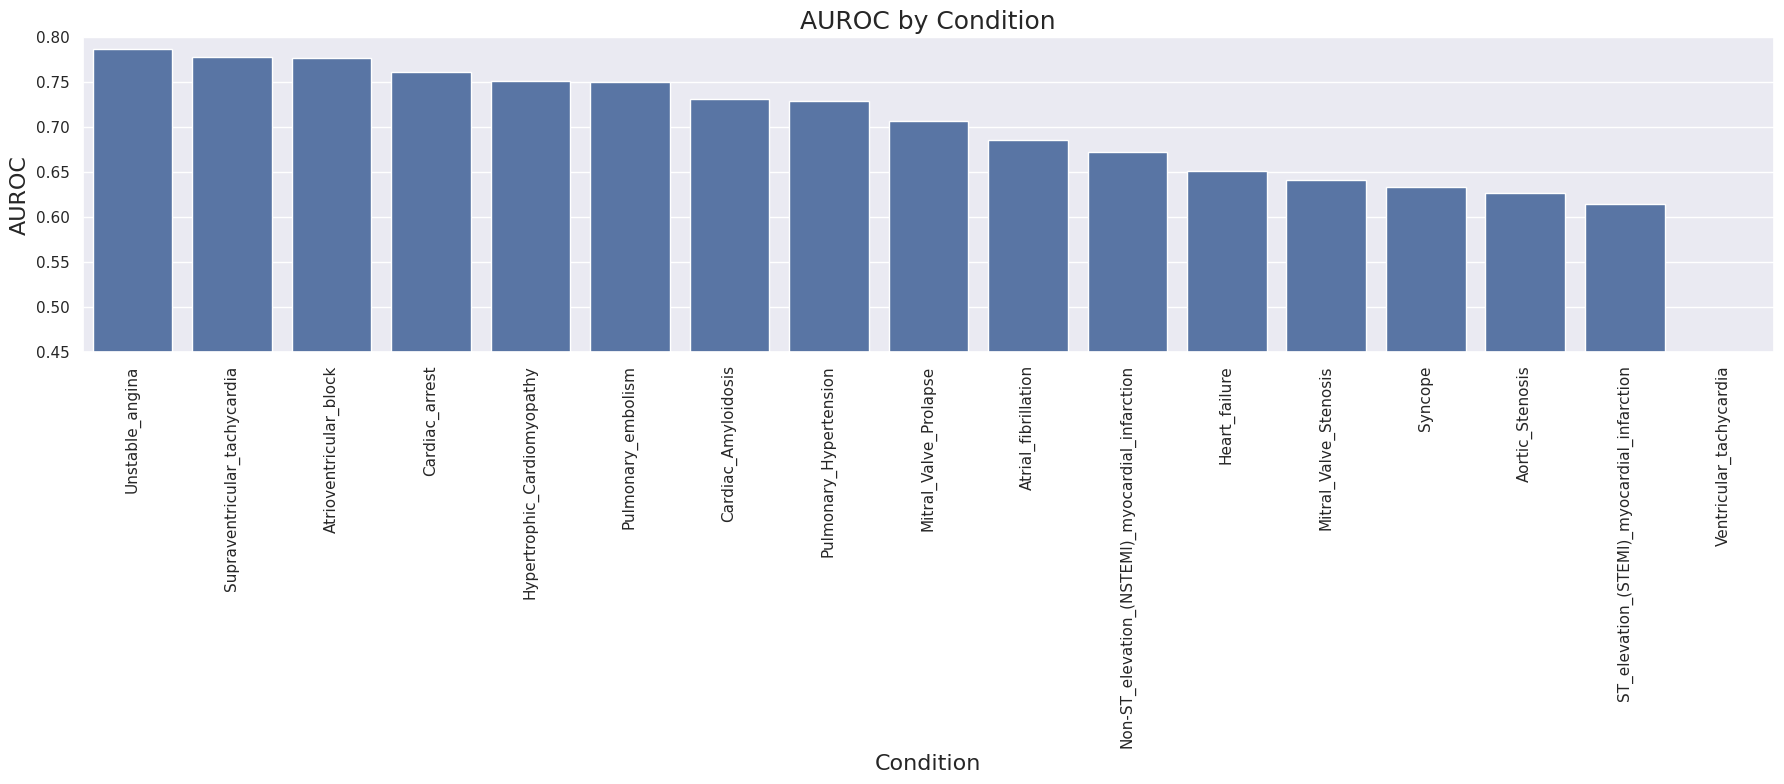

In [ ]:
from sklearn.metrics import roc_auc_score

auc_results = []

for i, condition in enumerate(demo_labels.columns):
    y_true = demo_labels.to_numpy()[:, i]
    y_score = y_prob[:, i]
    
    try:
        auc = roc_auc_score(y_true, y_score)
        auc_results.append([condition, auc])
    except ValueError:
        auc_results.append([condition, np.nan])

aucs_df = pd.DataFrame(auc_results, columns=["Condition", "AUROC"])
aucs_df = aucs_df.dropna().sort_values("AUROC", ascending=False)

print(aucs_df)

plt.figure(figsize=(18, 8))

ax = sns.barplot(data=aucs_df, x="Condition", y="AUROC")

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel("Condition", fontsize=16)
ax.set_ylabel("AUROC", fontsize=16)
ax.set_title("AUROC by Condition", fontsize=18)

plt.ylim(0.45, 0.8)
plt.tight_layout()
plt.show()